In [2]:
# -----------------------------
# PINN: Kovasznay flow (Re=40)
# -----------------------------
import scipy.io
import numpy as np
import tensorflow as tf
import sys
import os
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

sys.path.append(os.path.abspath(os.path.join(current_dir, '..')))
from model import PhysicsInformedNN

In [7]:
# ----------------------------
# Main 1: Train Kovasznay flow
# ----------------------------

if __name__ == "__main__": 
    
    # Hyperparameters configuration
    N_train = 5000
    layers = [3, 50, 50, 50, 50, 50, 50, 50, 50, 2]
    
    # Load simulation data
    data = scipy.io.loadmat('../Data/kovasznay_data.mat')
            
    U_star = data['U_star'] 
    P_star = data['p_star'] 
    t_star = data['t']      
    X_star = data['X_star'] 

    x_star = X_star[:,0:1]; y_star = X_star[:,1:2]
    N = X_star.shape[0]; T = t_star.shape[0]

    # Grid tile and data flattening
    XX = np.tile(X_star[:,0:1], (1,T)); YY = np.tile(X_star[:,1:2], (1,T)); TT = np.tile(t_star, (1,N)).T 
    UU = U_star[:,0,:]; VV = U_star[:,1,:]; PP = P_star 
    
    x = XX.flatten()[:,None]; y = YY.flatten()[:,None]; t = TT.flatten()[:,None] 
    u = UU.flatten()[:,None]; v = VV.flatten()[:,None]; p = PP.flatten()[:,None] 

    # Domain bounds
    lb = np.array([x.min(), y.min(), t.min()])
    ub = np.array([x.max(), y.max(), t.max()])
    lb_tf = tf.constant(lb, dtype=tf.float32)
    ub_tf = tf.constant(ub, dtype=tf.float32)

    # Random selection of training points
    idx = np.random.choice(N*T, N_train, replace=False)
    x_train = x[idx,:]; y_train = y[idx,:]; t_train = t[idx,:]
    u_train = u[idx,:]; v_train = v[idx,:]

    # Convert to TensorFlow tensors
    x_tf = tf.convert_to_tensor(x_train, dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)
    t_tf = tf.convert_to_tensor(t_train, dtype=tf.float32)
    u_tf = tf.convert_to_tensor(u_train, dtype=tf.float32)
    v_tf = tf.convert_to_tensor(v_train, dtype=tf.float32)

    # Training
    model = PhysicsInformedNN(layers, lb_tf, ub_tf)
    
    print("   >>> Phase 1: Data Fitting ...")
    model.train(x_tf, y_tf, t_tf, u_tf, v_tf, epochs=3000, train_params=False, physics_weight=0.0)

    model.reset_optimizer()

    print("   >>> Phase 2: Physics Discovery ...")
    model.train(x_tf, y_tf, t_tf, u_tf, v_tf, epochs=4000, train_params=True, physics_weight=1.0)
    

    # Prediction and Exportation
    snap = 90 
    if snap >= T: snap = T-1

    x_star_test = X_star[:,0:1]
    y_star_test = X_star[:,1:2]
    t_star_test = TT[:, snap] 
    
    x_test_tf = tf.reshape(tf.convert_to_tensor(x_star_test, dtype=tf.float32), [-1, 1])
    y_test_tf = tf.reshape(tf.convert_to_tensor(y_star_test, dtype=tf.float32), [-1, 1])
    t_test_tf = tf.reshape(tf.convert_to_tensor(t_star_test, dtype=tf.float32), [-1, 1])

    # Model prediction
    u_pred_tf, v_pred_tf, p_pred_tf, _, _ = model.net_NS(x_test_tf, y_test_tf, t_test_tf)
    
    u_pred = u_pred_tf.numpy()
    v_pred = v_pred_tf.numpy()
    p_pred = p_pred_tf.numpy()

    # Retrieve identified parameters
    lambda_1_value = model.lambda_1.numpy()[0]
    lambda_2_value = model.lambda_2.numpy()[0]

    # Retrieve loss history
    loss_total = np.array(model.loss_history['total'])
    loss_data = np.array(model.loss_history['data'])
    loss_phys = np.array(model.loss_history['phys'])

    # Save results to compressed .npz file
    np.savez('Results/Kovasznay/kovasznay_results.npz', 
             u_pred=u_pred, 
             v_pred=v_pred, 
             p_pred=p_pred, 
             lambda_1=lambda_1_value, 
             lambda_2=lambda_2_value,
             x_train=x_train, 
             y_train=y_train,
             snap=snap,
             loss_total=loss_total,
             loss_data=loss_data,
             loss_phys=loss_phys)
             
    print("Done!")

   >>> Phase 1: Data Fitting ...
Cause: Unable to locate the source code of <function PhysicsInformedNN.train.<locals>.compiled_step at 0x7b4a35897920>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function PhysicsInformedNN.train.<locals>.compiled_step at 0x7b4a35897920>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_co

/home/forero/Dev/venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:735: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


It: 0 [PARAMS:OFF|PHYS:OFF], Loss: 1.356e+00, l1: 1.0000, l2: 0.01000, Time: 6.40s
It: 100 [PARAMS:OFF|PHYS:OFF], Loss: 1.281e-01, l1: 1.0000, l2: 0.01000, Time: 74.46s
It: 200 [PARAMS:OFF|PHYS:OFF], Loss: 2.040e-02, l1: 1.0000, l2: 0.01000, Time: 75.63s
It: 300 [PARAMS:OFF|PHYS:OFF], Loss: 2.330e-02, l1: 1.0000, l2: 0.01000, Time: 76.24s
It: 400 [PARAMS:OFF|PHYS:OFF], Loss: 3.055e-03, l1: 1.0000, l2: 0.01000, Time: 75.21s
It: 500 [PARAMS:OFF|PHYS:OFF], Loss: 1.743e-03, l1: 1.0000, l2: 0.01000, Time: 70.11s
It: 600 [PARAMS:OFF|PHYS:OFF], Loss: 1.270e-03, l1: 1.0000, l2: 0.01000, Time: 71.04s
It: 700 [PARAMS:OFF|PHYS:OFF], Loss: 7.325e-03, l1: 1.0000, l2: 0.01000, Time: 70.19s
It: 800 [PARAMS:OFF|PHYS:OFF], Loss: 8.485e-04, l1: 1.0000, l2: 0.01000, Time: 70.04s
It: 900 [PARAMS:OFF|PHYS:OFF], Loss: 7.275e-04, l1: 1.0000, l2: 0.01000, Time: 70.52s
It: 1000 [PARAMS:OFF|PHYS:OFF], Loss: 6.333e-04, l1: 1.0000, l2: 0.01000, Time: 70.08s
It: 1100 [PARAMS:OFF|PHYS:OFF], Loss: 2.489e-03, l1: 1.0

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MaxNLocator  
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import griddata
from matplotlib.colors import TwoSlopeNorm
import matplotlib.ticker as ticker
import os

In [3]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 16
})

def plot_3d_surface(X, Y, Z, z_label, x_train, y_train, fig_size=(9, 8), plot_title=None, vmin=None, vmax=None, norm=None, ticks=None):
    """Función modular para graficar superficies 3D con normalización específica."""
    fig = plt.figure(figsize=fig_size)
    ax = fig.add_subplot(1, 1, 1, projection='3d')
    
    surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.9, edgecolor='none', 
                           vmin=vmin, vmax=vmax, norm=norm)

    if plot_title:
        ax.set_title(plot_title, fontsize=20, pad=15)
    
    # Axis configuration
    z_min = np.min(Z) - 0.2
    ax.set_zlim(z_min, np.max(Z))
    ax.scatter(x_train, y_train, np.full_like(x_train, z_min), c='k', marker='.', s=1, alpha=0.2)
    
    # Z-axis tick reduction to prevent saturation
    ax.zaxis.set_major_locator(MaxNLocator(nbins=4)) 
    
    ax.view_init(elev=35, azim=45)
    ax.set_xlabel('$x$', fontsize=18, labelpad=10)
    ax.set_ylabel('$y$', fontsize=18, labelpad=10)
    ax.set_zlabel(z_label, fontsize=18, rotation=0, labelpad=20)
    ax.set_box_aspect((1.5, 1.5, 0.5))
    
    # Color bar
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=15, pad=0.1, ticks=ticks)
    label_text = z_label.replace('$','').split('(')[0] 
    cbar.set_label(f'${label_text}$', rotation=0, labelpad=15, fontsize=16)
    
    return fig


--- PERFORMANCE METRICS ---
Relative L2 (U): 7.9307e-03
Relative L2 (V:) 5.5613e-02
Relative L2 (P): 2.7206e-02

--- PRESSURE RANGES ---
Predicted Pressure (PINN) | Min: 1.5797, Max: 2.8678, Range: 1.2882
Exact Pressure            | Min: -1.3107, Max: -0.0278, Range: 1.2830


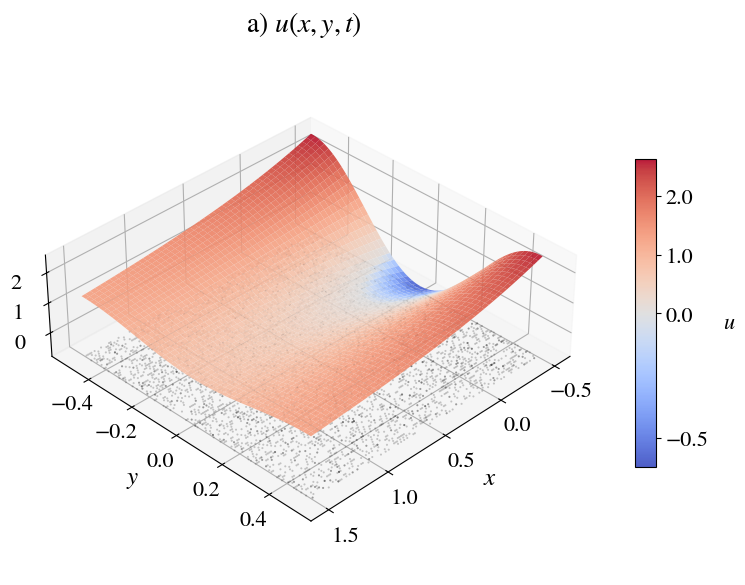

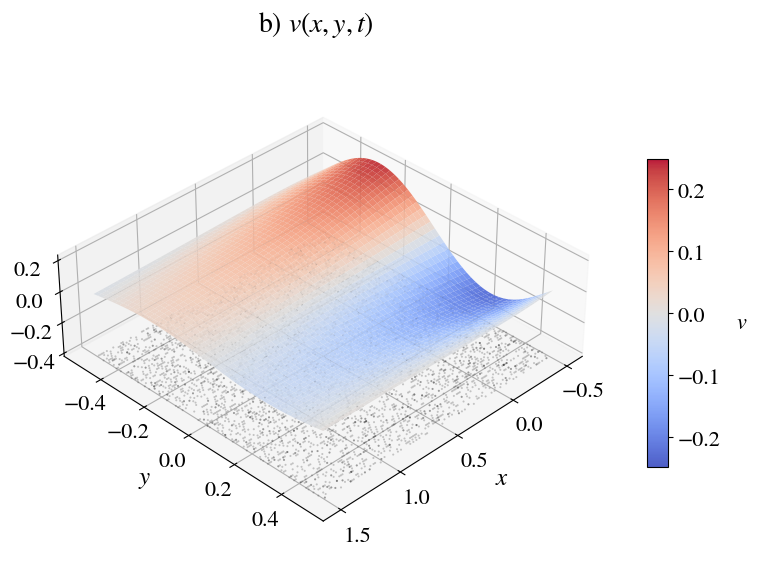

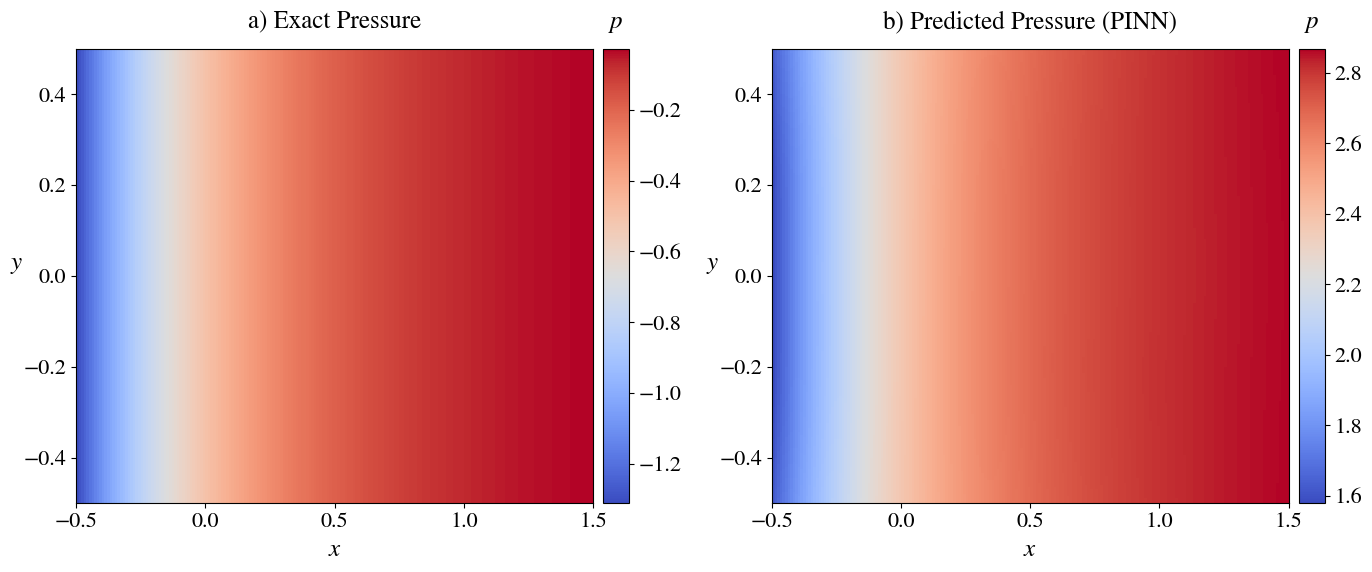

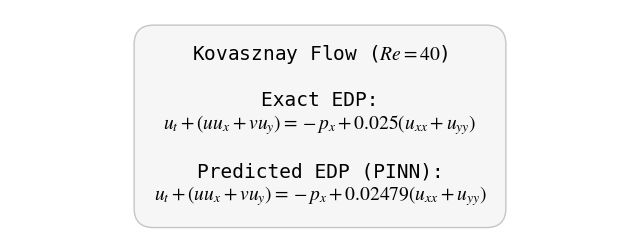

In [4]:
if __name__ == "__main__": 
    DATA_PATH = '../Data/kovasznay_data.mat' 
    RESULTS_PATH = 'Results/Kovasznay/kovasznay_results.npz'
    SAVE_DIR = 'Results/Kovasznay'
    os.makedirs(SAVE_DIR, exist_ok=True)

    # Load data
    data = scipy.io.loadmat(DATA_PATH)
    X_star = data['X_star']
    U_star = data['U_star'] # Shape: [N, 2, T]
    P_star = data['p_star'] # Shape: [N, T]

    results = np.load(RESULTS_PATH)

    u_pred = results['u_pred']
    v_pred = results['v_pred']
    p_pred = results['p_pred']

    lambda_1_value = float(results['lambda_1'])
    lambda_2_value = float(results['lambda_2'])

    x_train = results['x_train']
    y_train = results['y_train']
    snap = int(results['snap'])

    # Metrics
    p_exact = P_star[:, snap]
    u_exact = U_star[:, 0, snap]
    v_exact = U_star[:, 1, snap]

    error_u = np.linalg.norm(u_exact.flatten() - u_pred.flatten(), 2) / np.linalg.norm(u_exact.flatten(), 2)
    error_v = np.linalg.norm(v_exact.flatten() - v_pred.flatten(), 2) / np.linalg.norm(v_exact.flatten(), 2)

    # Pressure centering for relative error calculation
    p_pred_centered = p_pred.flatten() - np.mean(p_pred.flatten())
    p_exact_centered = p_exact.flatten() - np.mean(p_exact.flatten())

    error_p = np.linalg.norm(p_exact_centered - p_pred_centered, 2) / np.linalg.norm(p_exact_centered, 2)

    print(f"\n--- PERFORMANCE METRICS ---")
    print(f"Relative L2 (U): {error_u:.4e}")
    print(f"Relative L2 (V:) {error_v:.4e}")
    print(f"Relative L2 (P): {error_p:.4e}")

    # Min and max values
    p_pred_min, p_pred_max = np.min(p_pred), np.max(p_pred)
    p_exact_min, p_exact_max = np.min(p_exact), np.max(p_exact)

    print(f"\n--- PRESSURE RANGES ---")    
    print(f"Predicted Pressure (PINN) | Min: {p_pred_min:.4f}, Max: {p_pred_max:.4f}, Range: {p_pred_max - p_pred_min:.4f}")
    print(f"Exact Pressure            | Min: {p_exact_min:.4f}, Max: {p_exact_max:.4f}, Range: {p_exact_max - p_exact_min:.4f}")

    # Interpolation
    nn = 200
    x_plot = np.linspace(X_star[:,0].min(), X_star[:,0].max(), nn)
    y_plot = np.linspace(X_star[:,1].min(), X_star[:,1].max(), nn)
    X, Y = np.meshgrid(x_plot, y_plot)
    
    UU_star = griddata(X_star, u_pred.flatten(), (X, Y), method='cubic')
    VV_star = griddata(X_star, v_pred.flatten(), (X, Y), method='cubic')
    PP_star = griddata(X_star, p_pred.flatten(), (X, Y), method='cubic')
    U_exact_grid = griddata(X_star, u_exact.flatten(), (X, Y), method='cubic')
    V_exact_grid = griddata(X_star, v_exact.flatten(), (X, Y), method='cubic')
    P_exact_grid = griddata(X_star, p_exact.flatten(), (X, Y), method='cubic')

    # Plotting velocites (3D)
    vmin_u = min(np.min(U_exact_grid), np.min(UU_star))
    vmax_u = max(np.max(U_exact_grid), np.max(UU_star))
    norm_u = TwoSlopeNorm(vcenter=0, vmin=vmin_u, vmax=vmax_u)
    manual_ticks=[-0.5,0,1,2]
    
    fig_u = plot_3d_surface(X, Y, UU_star, '$u(x,y)$', x_train, y_train, fig_size=(9, 8), 
                        plot_title="a) $u(x,y,t)$", 
                        vmin=vmin_u, vmax=vmax_u, norm=norm_u, 
                        ticks=manual_ticks)

    fig_u.savefig(f'{SAVE_DIR}/Kovasznay_U.png', dpi=300, bbox_inches='tight')

    vmin_v = min(np.min(V_exact_grid), np.min(VV_star))
    vmax_v = max(np.max(V_exact_grid), np.max(VV_star))
    norm_v = TwoSlopeNorm(vcenter=0, vmin=vmin_v, vmax=vmax_v)
    
    fig_v = plot_3d_surface(X, Y, VV_star, '$v(x,y)$', x_train, y_train, 
                        plot_title="b) $v(x,y,t)$", 
                        vmin=vmin_v, vmax=vmax_v, norm=norm_v)
    fig_v.savefig(f'{SAVE_DIR}/Kovasznay_V.png', dpi=300, bbox_inches='tight')  

    # Pressure (2D Plots) 
    fig_pressure = plt.figure(figsize=(14, 6))
    data_list = [P_exact_grid, PP_star]
    title_list = ['a) Exact Pressure', 'b) Predicted Pressure (PINN)']
    
    for i, (data_p, title) in enumerate(zip(data_list, title_list)):
        ax = fig_pressure.add_subplot(1, 2, i+1)
        h = ax.imshow(data_p, interpolation='nearest', cmap='coolwarm', 
                      extent=[X_star[:,0].min(), X_star[:,0].max(), X_star[:,1].min(), X_star[:,1].max()], 
                      origin='lower', aspect='auto')
        ax.set_title(title, fontsize=18, pad=15)
        ax.set_xlabel('$x$', fontsize=18)
        ax.set_ylabel('$y$', fontsize=18, rotation=0, labelpad=5)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = fig_pressure.colorbar(h, cax=cax)
        cbar.ax.set_title('$p$', fontsize=18, pad=15)

    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/Kovasznay_P.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Discovery Results
    fig_results = plt.figure(figsize=(8, 3))
    ax_txt = fig_results.add_subplot(1, 1, 1)
    ax_txt.axis('off')

    
    txt = (f"Kovasznay Flow ($Re=40$)\n\n"
           f"Exact EDP:\n"
           f"$u_t + (u u_x + v u_y) = -p_x + 0.025(u_{{xx}} + u_{{yy}})$\n\n"
           f"Predicted EDP (PINN):\n"
           f"$u_t + (u u_x + v u_y) = -p_x + {lambda_2_value:.5f}(u_{{xx}} + u_{{yy}})$")

    ax_txt.text(0.5, 0.5, txt, fontsize=14, family='monospace', ha='center', va='center', 
                bbox=dict(facecolor='whitesmoke', alpha=0.9, edgecolor='silver', boxstyle='round,pad=1'))

    fig_results.savefig(f'{SAVE_DIR}/Kovasznay_Results.png', dpi=300, bbox_inches='tight')

    plt.show()
    plt.show()